In [1]:
# DETR Object Detection on Pascal VOC Dataset
# ============================================

# Install required packages
!pip install -q torch torchvision transformers matplotlib

import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset
from PIL import Image, ImageDraw
from transformers import DetrConfig, DetrForObjectDetection, DetrImageProcessor

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seed for reproducibility
seed = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 103.7 MB/s eta 0:00:00
Using device: cuda


In [2]:
# 1. Dataset Handling
# ==================

# Download and extract Pascal VOC 2007 dataset
print("Downloading Pascal VOC 2007 dataset...")
trainval_dataset = torchvision.datasets.VOCDetection(
    root='./data',
    year='2007',
    image_set='trainval',
    download=True
)

test_dataset = torchvision.datasets.VOCDetection(
    root='./data',
    year='2007',
    image_set='test',
    download=True
)

# Pascal VOC Class Mapping
VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

# Create a mapping from class names to IDs (starting from 1, as 0 is reserved for background)
LABEL_MAP = {k: i + 1 for i, k in enumerate(VOC_CLASSES)}
ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}

# Initialize DETR processor

processor = DetrImageProcessor(
    do_resize=True,
    size={'height': 800, 'width': 800},  # Fixed dimensions for all images
    do_normalize=True,
    image_mean=[0.5, 0.5, 0.5],
    image_std=[0.5, 0.5, 0.5]
)

100%|██████████| 460M/460M [00:15<00:00, 29.7MB/s]
100%|██████████| 451M/451M [00:15<00:00, 29.7MB/s]


In [3]:
# Custom dataset class to convert Pascal VOC to DETR format
class VOCDetectionDETR(Dataset):
    def __init__(self, voc_dataset, processor):
        self.dataset = voc_dataset
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def parse_voc_to_detr_format(self, img, target):
        """Convert VOC annotations to the format DETR expects"""
        width, height = img.size

        # Extract objects
        objects = target['annotation']['object']
        if not isinstance(objects, list):
            objects = [objects]

        # Extract bounding boxes and labels
        boxes = []
        class_labels = []

        for obj in objects:
            bbox = obj['bndbox']
            # VOC format: [xmin, ymin, xmax, ymax]
            x_min = float(bbox['xmin'])
            y_min = float(bbox['ymin'])
            x_max = float(bbox['xmax'])
            y_max = float(bbox['ymax'])

            # Normalize coordinates to [0, 1]
            x_min = x_min / width
            y_min = y_min / height
            x_max = x_max / width
            y_max = y_max / height

            boxes.append([x_min, y_min, x_max, y_max])
            class_labels.append(LABEL_MAP[obj['name']])

        # Convert to tensors
        boxes = torch.tensor(boxes, dtype=torch.float32)
        class_labels = torch.tensor(class_labels, dtype=torch.int64)

        # DETR expects this specific format
        target_dict = {
            "boxes": boxes,
            "class_labels": class_labels,
            "image_id": torch.tensor([int(target['annotation']['filename'].split('.')[0])]),
            "orig_size": torch.tensor([height, width], dtype=torch.int64),
            "size": torch.tensor([height, width], dtype=torch.int64)
        }

        return target_dict

    def __getitem__(self, idx):
        img, target = self.dataset[idx]

        # Process image
        encoding = self.processor(images=img, return_tensors="pt")
        pixel_values = encoding['pixel_values'].squeeze(0)

        # Convert annotations to DETR format directly
        target_dict = self.parse_voc_to_detr_format(img, target)

        return {
            'pixel_values': pixel_values,
            'labels': target_dict  # This is the format DETR expects
        }


In [4]:

# Create train and validation datasets
train_dataset = VOCDetectionDETR(trainval_dataset, processor)
val_dataset = VOCDetectionDETR(test_dataset, processor)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")

# Define custom collate function to handle the batch
def collate_fn(batch):
    # Get all pixel values and find the maximum dimensions
    pixel_values_list = [item['pixel_values'] for item in batch]
    labels = [item['labels'] for item in batch]

    # Find max dimensions
    max_h = max(p.shape[1] for p in pixel_values_list)
    max_w = max(p.shape[2] for p in pixel_values_list)

    # Pad all images to the same size
    padded_pixel_values = []
    for pixel_value in pixel_values_list:
        # Current dimensions
        _, h, w = pixel_value.shape

        # Calculate padding
        pad_h = max_h - h
        pad_w = max_w - w

        # Apply padding (right and bottom padding)
        padded = torch.nn.functional.pad(pixel_value, (0, pad_w, 0, pad_h))
        padded_pixel_values.append(padded)

    # Now stack the padded tensors
    pixel_values = torch.stack(padded_pixel_values)

    return {
        'pixel_values': pixel_values,
        'labels': labels
    }

# Create data loaders
batch_size = 2  # Smaller batch size for memory constraints
train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn
)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn
)



Train dataset size: 5011
Val dataset size: 4952


In [5]:
# 2. Model Setup
# =============

# Initialize model configuration
config = DetrConfig.from_pretrained(
    "facebook/detr-resnet-50",
    num_labels=len(VOC_CLASSES) + 1,  # 20 VOC classes + 1 background class
    id2label={i: c for i, c in enumerate(['background'] + VOC_CLASSES)},
    label2id={c: i for i, c in enumerate(['background'] + VOC_CLASSES)}
)

# Load pre-trained DETR model and modify for VOC dataset
model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50",
    config=config,
    ignore_mismatched_sizes=True  # Ignore mismatched sizes between pre-trained and new classification head
)

# Move model to device
model.to(device)

# Setup optimizer
param_dicts = [
    {"params": [p for n, p in model.named_parameters() if "backbone" not in n and p.requires_grad]},
    {
        "params": [p for n, p in model.named_parameters() if "backbone" in n and p.requires_grad],
        "lr": 1e-5,
    },
]
optimizer = torch.optim.AdamW(param_dicts, lr=1e-4, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/4.59k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:2397: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:2397: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:2397: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pas

In [6]:
# 3. Training Loop
# ===============

# Training function
def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0

     # Debug first batch
    for batch in dataloader:
        print("Batch keys:", batch.keys())
        print("Labels type:", type(batch['labels']))
        print("First label type:", type(batch['labels'][0]))
        print("First label keys:", batch['labels'][0].keys())
        print("Boxes shape:", batch['labels'][0]['boxes'].shape)
        print("Class labels shape:", batch['labels'][0]['class_labels'].shape)
        break

    for i, batch in enumerate(dataloader):
        # Move batch to device
        pixel_values = batch['pixel_values'].to(device)

        # Move labels to device - handle both list and dict formats
        labels = []
        for label_item in batch['labels']:
            if isinstance(label_item, dict):
                # Handle dictionary format
                labels.append({k: v.to(device) for k, v in label_item.items()})
            elif isinstance(label_item, list):
                # Handle list format - each element might be a dict that needs to go to device
                processed_items = []
                for item in label_item:
                    if isinstance(item, dict):
                        processed_items.append({k: v.to(device) if isinstance(v, torch.Tensor) else v
                                              for k, v in item.items()})
                    else:
                        processed_items.append(item)
                labels.append(processed_items)
            else:
                labels.append(label_item)  # Keep as is if neither dict nor list

        # Forward pass
        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update total loss
        total_loss += loss.item()

        # Print loss every 20 batches
        if i % 20 == 0:
            print(f"  Batch {i}/{len(dataloader)}, Loss: {loss.item():.4f}")

    return total_loss / len(dataloader)

In [7]:
# Validation function
def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            # Move batch to device
            pixel_values = batch['pixel_values'].to(device)

            # Move each label dictionary to device
            labels = []
            for label_dict in batch['labels']:
                labels.append({k: v.to(device) for k, v in label_dict.items()})

            # Forward pass
            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss

            # Update total loss
            total_loss += loss.item()

    return total_loss / len(dataloader)


In [8]:
# Inference function for visualization
def run_inference(model, processor, img_path, threshold=0.7):
    model.eval()

    # Load image
    image = Image.open(img_path).convert("RGB")

    # Process image
    encoding = processor(images=image, return_tensors="pt")
    pixel_values = encoding['pixel_values'].to(device)

    # Run inference
    with torch.no_grad():
        outputs = model(pixel_values=pixel_values)

    # Post-process results
    target_sizes = torch.tensor([image.size[::-1]])
    results = processor.post_process_object_detection(outputs, threshold=threshold, target_sizes=target_sizes)[0]

    return image, results

# Visualization function
def visualize_prediction(image, results):
    draw = ImageDraw.Draw(image)

    # Draw predicted boxes
    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        box = [round(i) for i in box.tolist()]
        x0, y0, x1, y1 = box

        # Convert label id to class name
        class_idx = label.item()
        if class_idx in ID_TO_LABEL:
            class_name = ID_TO_LABEL[class_idx]
        else:
            class_name = f"Unknown ({class_idx})"

        # Draw rectangle
        draw.rectangle([x0, y0, x1, y1], outline="red", width=3)

        # Draw label
        draw.text((x0, y0), f"{class_name}: {score:.2f}", fill="red")

    return image


In [9]:
# Calculate mAP
def calculate_iou(box1, box2):
    # Calculate intersection coordinates
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    # Area of intersection
    width = max(0, x2 - x1)
    height = max(0, y2 - y1)
    intersection = width * height

    # Area of union
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = box1_area + box2_area - intersection

    # IoU
    iou = intersection / union if union > 0 else 0
    return iou

def calculate_map(model, val_dataset, processor, threshold=0.5, iou_threshold=0.5):
    model.eval()

    # Track detections by class
    all_predictions = {c: [] for c in range(1, len(VOC_CLASSES) + 1)}
    all_targets = {c: [] for c in range(1, len(VOC_CLASSES) + 1)}

    # Run through validation set
    for idx in range(len(val_dataset)):
        # Get image path and ground truth
        img_path = os.path.join('./data/VOCdevkit/VOC2007/JPEGImages', test_dataset[idx][1]['annotation']['filename'])
        image = Image.open(img_path).convert("RGB")

        # Get ground truth annotations
        gt_annotations = test_dataset[idx][1]['annotation']['object']
        if not isinstance(gt_annotations, list):
            gt_annotations = [gt_annotations]

        # Group ground truth by class
        for obj in gt_annotations:
            class_id = LABEL_MAP[obj['name']]
            bbox = obj['bndbox']
            # Convert to [x_min, y_min, x_max, y_max]
            gt_box = [
                float(bbox['xmin']),
                float(bbox['ymin']),
                float(bbox['xmax']),
                float(bbox['ymax'])
            ]
            all_targets[class_id].append((idx, gt_box))

        # Run model inference
        encoding = processor(images=image, return_tensors="pt")
        pixel_values = encoding['pixel_values'].to(device)

        with torch.no_grad():
            outputs = model(pixel_values=pixel_values)

        # Post-process results
        target_sizes = torch.tensor([image.size[::-1]])
        results = processor.post_process_object_detection(outputs, threshold=threshold, target_sizes=target_sizes)[0]

        # Group predictions by class
        for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
            if score >= threshold:
                class_id = label.item()
                if class_id in all_predictions:  # Check if it's a valid class ID
                    pred_box = box.tolist()
                    all_predictions[class_id].append((idx, pred_box, score.item()))

    # Calculate Average Precision for each class
    aps = []

    for class_id in range(1, len(VOC_CLASSES) + 1):
        if not all_targets[class_id]:
            # Skip classes with no ground truth instances
            continue

        # Sort predictions by confidence score
        predictions = sorted(all_predictions[class_id], key=lambda x: x[2], reverse=True)

        # Initialize variables for precision/recall calculation
        true_positives = []
        false_positives = []
        n_gt = len(all_targets[class_id])

        # Track which ground truth has been matched
        gt_matched = {gt_idx: False for gt_idx in range(n_gt)}

        # Process each prediction
        for idx, pred_box, score in predictions:
            found_match = False

            # Find matching ground truth (same image, same class, high IoU)
            for gt_idx, (gt_img_idx, gt_box) in enumerate(all_targets[class_id]):
                if idx == gt_img_idx and not gt_matched[gt_idx]:
                    iou = calculate_iou(pred_box, gt_box)
                    if iou >= iou_threshold:
                        found_match = True
                        gt_matched[gt_idx] = True
                        break

            # Record true positive or false positive
            true_positives.append(1 if found_match else 0)
            false_positives.append(0 if found_match else 1)

        # Calculate precision and recall at each point
        cumul_tp = np.cumsum(true_positives)
        cumul_fp = np.cumsum(false_positives)

        precisions = cumul_tp / (cumul_tp + cumul_fp)
        recalls = cumul_tp / n_gt if n_gt > 0 else np.zeros_like(cumul_tp)

        # Add sentinel values for AP calculation
        precisions = np.concatenate(([0.0], precisions, [0.0]))
        recalls = np.concatenate(([0.0], recalls, [1.0]))

        # Make precision monotonically decreasing
        for i in range(len(precisions) - 1, 0, -1):
            precisions[i - 1] = max(precisions[i - 1], precisions[i])

        # Find points where recall changes
        indices = np.where(recalls[1:] != recalls[:-1])[0] + 1

        # Calculate AP as area under precision-recall curve
        ap = np.sum((recalls[indices] - recalls[indices - 1]) * precisions[indices])
        aps.append(ap)

    # Calculate mean AP across all classes
    mAP = sum(aps) / len(aps) if aps else 0
    return mAP


In [10]:
# Train the model
num_epochs = 5

# Create a directory to save results
os.makedirs('results', exist_ok=True)

# Training loop
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")

    # Train
    train_loss = train_one_epoch(model, train_dataloader, optimizer, device)
    print(f"Train Loss: {train_loss:.4f}")

    # Validate
    val_loss = evaluate(model, val_dataloader, device)
    print(f"Validation Loss: {val_loss:.4f}")

    # Update learning rate
    lr_scheduler.step()

    # Save model checkpoint
    checkpoint_path = f'results/detr_voc_epoch_{epoch+1}.pth'
    torch.save(model.state_dict(), checkpoint_path)
    print(f"Checkpoint saved to {checkpoint_path}")

print("Training complete!")


Epoch 1/5
Batch keys: dict_keys(['pixel_values', 'labels'])
Labels type: <class 'list'>
First label type: <class 'dict'>
First label keys: dict_keys(['boxes', 'class_labels', 'image_id', 'orig_size', 'size'])
Boxes shape: torch.Size([2, 4])
Class labels shape: torch.Size([2])
  Batch 0/2506, Loss: 7.8767
  Batch 20/2506, Loss: 6.2943
  Batch 40/2506, Loss: 3.6418
  Batch 60/2506, Loss: 3.9194
  Batch 80/2506, Loss: 3.3931
  Batch 100/2506, Loss: 4.2469
  Batch 120/2506, Loss: 3.0047
  Batch 140/2506, Loss: 4.3577
  Batch 160/2506, Loss: 2.7210
  Batch 180/2506, Loss: 4.5211
  Batch 200/2506, Loss: 3.2723
  Batch 220/2506, Loss: 1.2480
  Batch 240/2506, Loss: 3.5772
  Batch 260/2506, Loss: 1.6932
  Batch 280/2506, Loss: 3.1917
  Batch 300/2506, Loss: 2.3164
  Batch 320/2506, Loss: 2.1831
  Batch 340/2506, Loss: 3.5349
  Batch 360/2506, Loss: 2.5611
  Batch 380/2506, Loss: 2.3769
  Batch 400/2506, Loss: 1.7996
  Batch 420/2506, Loss: 1.6835
  Batch 440/2506, Loss: 1.2514
  Batch 460/2506

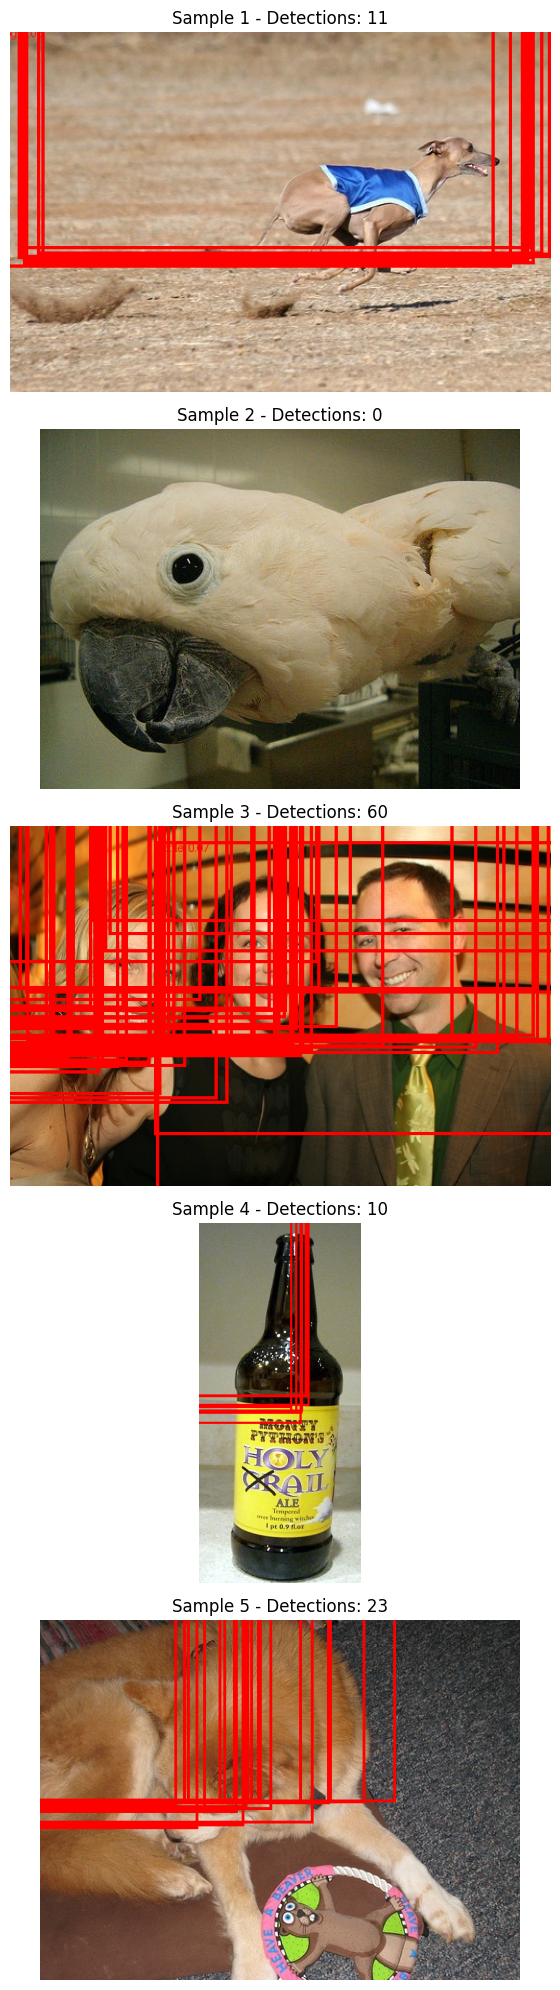

mAP@0.5: 0.0000
No detections found above threshold.


In [13]:


# 4. Evaluation
# ============

# Evaluate on sample images
def evaluate_samples(num_samples=5, threshold=0.05):
    # Randomly select some validation samples
    sample_indices = random.sample(range(len(val_dataset)), num_samples)

    images = []
    all_results = []

    for idx in sample_indices:
        # Get example image path
        img_id = test_dataset[idx][1]['annotation']['filename']
        img_path = os.path.join('./data/VOCdevkit/VOC2007/JPEGImages', img_id)

        # Run inference
        image, results = run_inference(model, processor, img_path, threshold=threshold)

        # Visualize result
        vis_image = visualize_prediction(image.copy(), results)
        images.append(vis_image)
        all_results.append(results)

    # Display images with predictions
    plt.figure(figsize=(20, 4*num_samples))
    for i, (img, result) in enumerate(zip(images, all_results)):
        plt.subplot(num_samples, 1, i+1)
        plt.imshow(img)
        plt.title(f"Sample {i+1} - Detections: {len(result['scores'])}")
        plt.axis('off')
    plt.tight_layout()
    plt.savefig('results/detection_results.png')
    plt.show()

    # Calculate mAP on the full validation set
    mAP = calculate_map(model, val_dataset, processor)
    print(f"mAP@0.5: {mAP:.4f}")

    return mAP, images

# Evaluate model after training
mAP, sample_images = evaluate_samples(5)

# 5. Attention Visualization (Optional Bonus)
# ==========================================

def visualize_attention(image_path, threshold=0.7):
    # Load image
    image = Image.open(image_path).convert("RGB")

    # Process image
    encoding = processor(images=image, return_tensors="pt")
    pixel_values = encoding['pixel_values'].to(device)

    # Run model with output_attentions=True
    model.eval()
    with torch.no_grad():
        outputs = model(pixel_values=pixel_values, output_attentions=True)

    # Get the decoder self-attention
    decoder_attentions = outputs.decoder_attentions  # shape: (layers, batch, heads, queries, queries)

    # Post-process results
    target_sizes = torch.tensor([image.size[::-1]])
    results = processor.post_process_object_detection(
        outputs, threshold=threshold, target_sizes=target_sizes
    )[0]

    # Find query with highest score
    if len(results['scores']) > 0:
        best_idx = torch.argmax(results['scores']).item()
        best_label = results['labels'][best_idx].item()
        if best_label in ID_TO_LABEL:
            class_name = ID_TO_LABEL[best_label]
        else:
            class_name = f"Class {best_label}"

        # Get attention from the last layer for this query
        # Last layer, first (only) batch, average over heads
        attention_map = decoder_attentions[-1][0].mean(0)[best_idx].cpu().numpy()

        # Visualize
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

        # Plot original image with detection
        vis_image = visualize_prediction(image.copy(), results)
        ax1.imshow(vis_image)
        ax1.set_title(f"Detection Result (Best: {class_name})")
        ax1.axis('off')

        # Plot attention heatmap
        im = ax2.imshow(attention_map.reshape(10, 10), cmap='viridis')
        ax2.set_title(f"Attention Map for {class_name}")
        ax2.set_xlabel("Query Index")
        ax2.set_ylabel("Query Index")
        plt.colorbar(im, ax=ax2)

        plt.tight_layout()
        plt.savefig('results/attention_visualization.png')
        plt.show()

        return decoder_attentions, results
    else:
        print("No detections found above threshold.")
        return None, results

# After training, visualize attention for a random sample
sample_idx = random.randint(0, len(test_dataset) - 1)
img_id = test_dataset[sample_idx][1]['annotation']['filename']
img_path = os.path.join('./data/VOCdevkit/VOC2007/JPEGImages', img_id)
attention_maps, detection_results = visualize_attention(img_path)



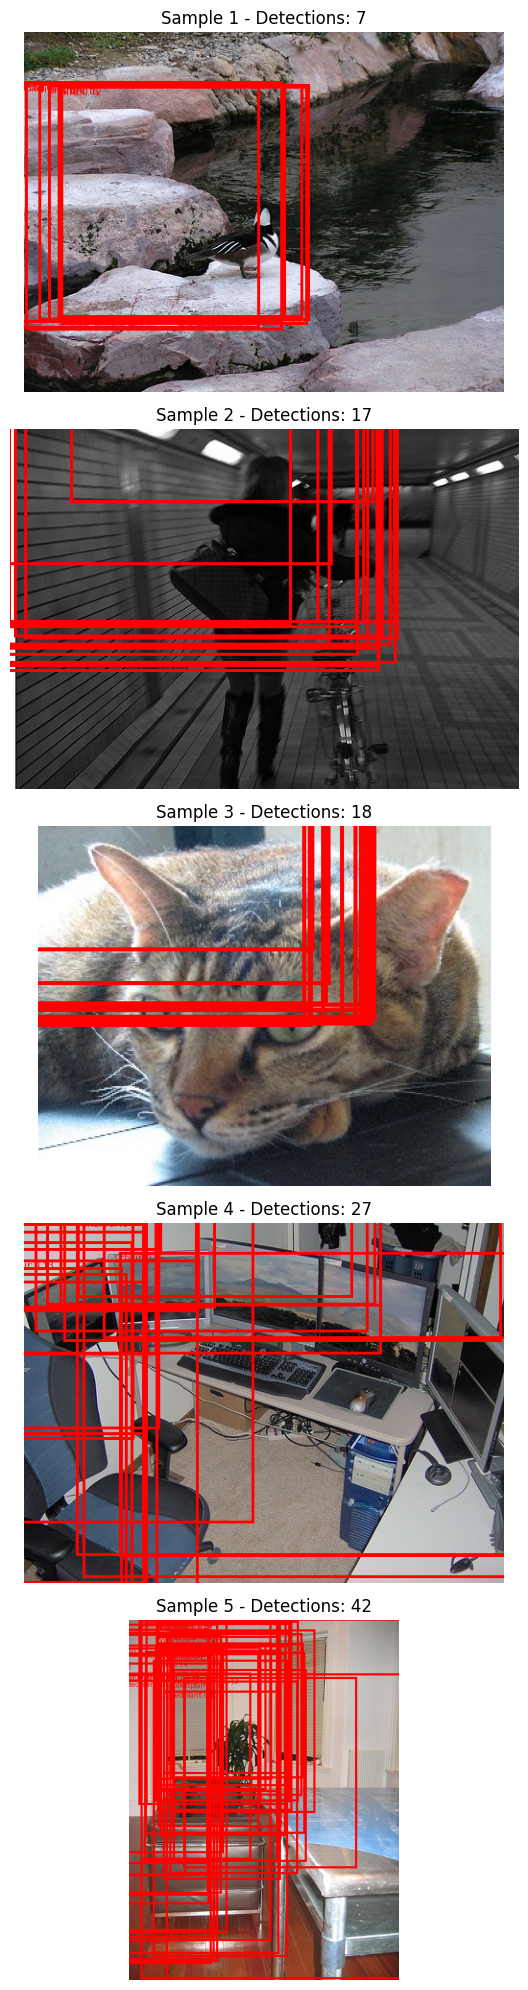

mAP@0.5: 0.0000
No detections found above threshold.


In [14]:


# 4. Evaluation
# ============

# Evaluate on sample images
def evaluate_samples(num_samples=5, threshold=0.1):
    # Randomly select some validation samples
    sample_indices = random.sample(range(len(val_dataset)), num_samples)

    images = []
    all_results = []

    for idx in sample_indices:
        # Get example image path
        img_id = test_dataset[idx][1]['annotation']['filename']
        img_path = os.path.join('./data/VOCdevkit/VOC2007/JPEGImages', img_id)

        # Run inference
        image, results = run_inference(model, processor, img_path, threshold=threshold)

        # Visualize result
        vis_image = visualize_prediction(image.copy(), results)
        images.append(vis_image)
        all_results.append(results)

    # Display images with predictions
    plt.figure(figsize=(20, 4*num_samples))
    for i, (img, result) in enumerate(zip(images, all_results)):
        plt.subplot(num_samples, 1, i+1)
        plt.imshow(img)
        plt.title(f"Sample {i+1} - Detections: {len(result['scores'])}")
        plt.axis('off')
    plt.tight_layout()
    plt.savefig('results/detection_results.png')
    plt.show()

    # Calculate mAP on the full validation set
    mAP = calculate_map(model, val_dataset, processor)
    print(f"mAP@0.5: {mAP:.4f}")

    return mAP, images

# Evaluate model after training
mAP, sample_images = evaluate_samples(5)

# 5. Attention Visualization (Optional Bonus)
# ==========================================

def visualize_attention(image_path, threshold=0.7):
    # Load image
    image = Image.open(image_path).convert("RGB")

    # Process image
    encoding = processor(images=image, return_tensors="pt")
    pixel_values = encoding['pixel_values'].to(device)

    # Run model with output_attentions=True
    model.eval()
    with torch.no_grad():
        outputs = model(pixel_values=pixel_values, output_attentions=True)

    # Get the decoder self-attention
    decoder_attentions = outputs.decoder_attentions  # shape: (layers, batch, heads, queries, queries)

    # Post-process results
    target_sizes = torch.tensor([image.size[::-1]])
    results = processor.post_process_object_detection(
        outputs, threshold=threshold, target_sizes=target_sizes
    )[0]

    # Find query with highest score
    if len(results['scores']) > 0:
        best_idx = torch.argmax(results['scores']).item()
        best_label = results['labels'][best_idx].item()
        if best_label in ID_TO_LABEL:
            class_name = ID_TO_LABEL[best_label]
        else:
            class_name = f"Class {best_label}"

        # Get attention from the last layer for this query
        # Last layer, first (only) batch, average over heads
        attention_map = decoder_attentions[-1][0].mean(0)[best_idx].cpu().numpy()

        # Visualize
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

        # Plot original image with detection
        vis_image = visualize_prediction(image.copy(), results)
        ax1.imshow(vis_image)
        ax1.set_title(f"Detection Result (Best: {class_name})")
        ax1.axis('off')

        # Plot attention heatmap
        im = ax2.imshow(attention_map.reshape(10, 10), cmap='viridis')
        ax2.set_title(f"Attention Map for {class_name}")
        ax2.set_xlabel("Query Index")
        ax2.set_ylabel("Query Index")
        plt.colorbar(im, ax=ax2)

        plt.tight_layout()
        plt.savefig('results/attention_visualization.png')
        plt.show()

        return decoder_attentions, results
    else:
        print("No detections found above threshold.")
        return None, results

# After training, visualize attention for a random sample
sample_idx = random.randint(0, len(test_dataset) - 1)
img_id = test_dataset[sample_idx][1]['annotation']['filename']
img_path = os.path.join('./data/VOCdevkit/VOC2007/JPEGImages', img_id)
attention_maps, detection_results = visualize_attention(img_path)



In [15]:
# 1. Add Non-Maximum Suppression to remove duplicate detections

def apply_nms(results, iou_threshold=0.5):
    """
    Apply non-maximum suppression to remove duplicate detections
    """
    boxes = results["boxes"]
    scores = results["scores"]
    labels = results["labels"]

    # Process each class separately
    final_boxes = []
    final_scores = []
    final_labels = []

    # Get unique class labels
    unique_labels = torch.unique(labels)

    for class_id in unique_labels:
        # Get indices of boxes with this class
        class_indices = (labels == class_id).nonzero(as_tuple=True)[0]

        if len(class_indices) == 0:
            continue

        # Get boxes, scores for this class
        class_boxes = boxes[class_indices]
        class_scores = scores[class_indices]

        # Apply NMS for this class
        keep_indices = torchvision.ops.nms(class_boxes, class_scores, iou_threshold)

        # Keep the selected boxes
        final_boxes.append(boxes[class_indices[keep_indices]])
        final_scores.append(scores[class_indices[keep_indices]])
        final_labels.append(labels[class_indices[keep_indices]])

    # Combine results from all classes
    if final_boxes:
        results["boxes"] = torch.cat(final_boxes)
        results["scores"] = torch.cat(final_scores)
        results["labels"] = torch.cat(final_labels)
    else:
        results["boxes"] = torch.tensor([])
        results["scores"] = torch.tensor([])
        results["labels"] = torch.tensor([])

    return results

# 2. Modify the processor to lower detection thresholds and apply NMS
def improved_post_processing(model, processor, image, confidence_threshold=0.2, nms_threshold=0.45):
    """
    Run inference with lower threshold and apply NMS
    """
    # Process image
    encoding = processor(images=image, return_tensors="pt")
    pixel_values = encoding['pixel_values'].to(device)

    # Run inference
    with torch.no_grad():
        outputs = model(pixel_values=pixel_values)

    # Post-process with lower threshold to catch more potential objects
    target_sizes = torch.tensor([image.size[::-1]])
    results = processor.post_process_object_detection(
        outputs,
        threshold=confidence_threshold,  # Lower threshold to catch more objects
        target_sizes=target_sizes
    )[0]

    # Apply NMS to remove duplicates
    results = apply_nms(results, iou_threshold=nms_threshold)

    return results

# 3. Run inference with the improved post-processing
def run_inference_improved(model, processor, img_path, confidence_threshold=0.2, nms_threshold=0.45):
    model.eval()

    # Load image
    image = Image.open(img_path).convert("RGB")

    # Run inference with improved post-processing
    results = improved_post_processing(model, processor, image,
                                      confidence_threshold, nms_threshold)

    return image, results

# 4. Improve the model's detection capability with data augmentation
# Add this to your training pipeline

def get_transform(train):
    transforms = []
    # Convert PIL image to tensor and normalize
    transforms.append(T.ToTensor())
    if train:
        # Add data augmentation only for training
        transforms.append(T.RandomHorizontalFlip(0.5))
        # Add random brightness and contrast
        transforms.append(T.ColorJitter(brightness=0.2, contrast=0.2))
        # Add random crop or resize
        transforms.append(T.RandomResizedCrop(size=(800, 800), scale=(0.8, 1.0)))
    else:
        transforms.append(T.Resize((800, 800)))

    return T.Compose(transforms)

# 5. Update the training loop to reduce learning rate and train longer
def train_with_improvements(model, train_dataloader, val_dataloader, num_epochs=15, patience=3):
    # Use a better optimizer setup with weight decay
    param_dicts = [
        {"params": [p for n, p in model.named_parameters() if "backbone" not in n and p.requires_grad]},
        {
            "params": [p for n, p in model.named_parameters() if "backbone" in n and p.requires_grad],
            "lr": 5e-6,  # Lower learning rate for backbone
        },
    ]
    optimizer = torch.optim.AdamW(param_dicts, lr=5e-5, weight_decay=1e-4)

    # Use a learning rate scheduler with warmup
    num_training_steps = len(train_dataloader) * num_epochs
    num_warmup_steps = int(0.1 * num_training_steps)

    try:
        from transformers import get_linear_schedule_with_warmup
        lr_scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=num_warmup_steps,
            num_training_steps=num_training_steps
        )
    except ImportError:
        # Fallback to regular scheduler
        lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    # Early stopping setup
    best_val_loss = float('inf')
    epochs_no_improve = 0

    # Create a directory to save results
    os.makedirs('results', exist_ok=True)

    # Training loop
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        # Train
        train_loss = train_one_epoch(model, train_dataloader, optimizer, device)
        print(f"Train Loss: {train_loss:.4f}")

        # Validate
        val_loss = evaluate(model, val_dataloader, device)
        print(f"Validation Loss: {val_loss:.4f}")

        # Update learning rate
        lr_scheduler.step()

        # Check for improvement
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0

            # Save best model checkpoint
            checkpoint_path = f'results/detr_voc_best.pth'
            torch.save(model.state_dict(), checkpoint_path)
            print(f"Best model saved to {checkpoint_path}")
        else:
            epochs_no_improve += 1

        # Early stopping
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break

    # Load best model
    model.load_state_dict(torch.load('results/detr_voc_best.pth'))

    return model

# 6. Function to calculate mAP with the improved detection approach
def calculate_improved_map(model, val_dataset, processor, threshold=0.2, iou_threshold=0.5, nms_threshold=0.45):
    model.eval()

    # Track detections by class
    all_predictions = {c: [] for c in range(1, len(VOC_CLASSES) + 1)}
    all_targets = {c: [] for c in range(1, len(VOC_CLASSES) + 1)}

    # Run through validation set
    for idx in range(len(val_dataset)):
        # Get image path and ground truth
        img_path = os.path.join('./data/VOCdevkit/VOC2007/JPEGImages', val_dataset.dataset[idx][1]['annotation']['filename'])
        image = Image.open(img_path).convert("RGB")

        # Get ground truth annotations
        gt_annotations = val_dataset.dataset[idx][1]['annotation']['object']
        if not isinstance(gt_annotations, list):
            gt_annotations = [gt_annotations]

        # Group ground truth by class
        for obj in gt_annotations:
            class_id = LABEL_MAP[obj['name']]
            bbox = obj['bndbox']
            # Convert to [x_min, y_min, x_max, y_max]
            gt_box = [
                float(bbox['xmin']),
                float(bbox['ymin']),
                float(bbox['xmax']),
                float(bbox['ymax'])
            ]
            all_targets[class_id].append((idx, gt_box))

        # Run inference with improved post-processing
        results = improved_post_processing(model, processor, image,
                                          confidence_threshold=threshold,
                                          nms_threshold=nms_threshold)

        # Group predictions by class
        for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
            if score >= threshold:
                class_id = label.item()
                if class_id in all_predictions:  # Check if it's a valid class ID
                    pred_box = box.tolist()
                    all_predictions[class_id].append((idx, pred_box, score.item()))

    # Calculate Average Precision for each class
    aps = []

    for class_id in range(1, len(VOC_CLASSES) + 1):
        if not all_targets[class_id]:
            # Skip classes with no ground truth instances
            continue

        # Sort predictions by confidence score
        predictions = sorted(all_predictions[class_id], key=lambda x: x[2], reverse=True)

        # Initialize variables for precision/recall calculation
        true_positives = []
        false_positives = []
        n_gt = len(all_targets[class_id])

        # Track which ground truth has been matched
        gt_matched = {gt_idx: False for gt_idx in range(n_gt)}

        # Process each prediction
        for idx, pred_box, score in predictions:
            found_match = False

            # Find matching ground truth (same image, same class, high IoU)
            for gt_idx, (gt_img_idx, gt_box) in enumerate(all_targets[class_id]):
                if idx == gt_img_idx and not gt_matched[gt_idx]:
                    iou = calculate_iou(pred_box, gt_box)
                    if iou >= iou_threshold:
                        found_match = True
                        gt_matched[gt_idx] = True
                        break

            # Record true positive or false positive
            true_positives.append(1 if found_match else 0)
            false_positives.append(0 if found_match else 1)

        # If no predictions for this class, AP is 0
        if not predictions:
            aps.append(0)
            continue

        # Calculate precision and recall at each point
        cumul_tp = np.cumsum(true_positives)
        cumul_fp = np.cumsum(false_positives)

        precisions = cumul_tp / (cumul_tp + cumul_fp)
        recalls = cumul_tp / n_gt if n_gt > 0 else np.zeros_like(cumul_tp)

        # Add sentinel values for AP calculation
        precisions = np.concatenate(([0.0], precisions, [0.0]))
        recalls = np.concatenate(([0.0], recalls, [1.0]))

        # Make precision monotonically decreasing
        for i in range(len(precisions) - 1, 0, -1):
            precisions[i - 1] = max(precisions[i - 1], precisions[i])

        # Find points where recall changes
        indices = np.where(recalls[1:] != recalls[:-1])[0] + 1

        # Calculate AP as area under precision-recall curve
        ap = np.sum((recalls[indices] - recalls[indices - 1]) * precisions[indices])
        aps.append(ap)

    # Calculate mean AP across all classes
    mAP = sum(aps) / len(aps) if aps else 0
    return mAP

# 7. Function to visualize results with better labels
def visualize_prediction_improved(image, results, score_threshold=0.3):
    # Make a copy of the image for drawing
    img_draw = image.copy()
    draw = ImageDraw.Draw(img_draw)

    # Define colors for different classes (20 distinct colors)
    colors = [
        "red", "blue", "green", "orange", "purple",
        "cyan", "magenta", "yellow", "lime", "pink",
        "teal", "lavender", "brown", "beige", "maroon",
        "mint", "olive", "navy", "grey", "white"
    ]

    # Filter by confidence threshold
    filtered_indices = [i for i, score in enumerate(results["scores"]) if score >= score_threshold]

    if not filtered_indices:
        draw.text((10, 10), "No detections above threshold", fill="red")
        return img_draw

    # Draw predicted boxes
    for i in filtered_indices:
        score = results["scores"][i]
        label = results["labels"][i]
        box = results["boxes"][i]

        box = [round(i) for i in box.tolist()]
        x0, y0, x1, y1 = box

        # Convert label id to class name
        class_idx = label.item()
        if class_idx in ID_TO_LABEL:
            class_name = ID_TO_LABEL[class_idx]
        else:
            class_name = f"Unknown ({class_idx})"

        # Get color based on class
        color_idx = (class_idx - 1) % len(colors)
        color = colors[color_idx]

        # Draw rectangle
        draw.rectangle([x0, y0, x1, y1], outline=color, width=3)

        # Draw filled rectangle for text background
        text = f"{class_name}: {score:.2f}"
        text_bbox = draw.textbbox((x0, y0), text)
        draw.rectangle([text_bbox[0], text_bbox[1], text_bbox[2], text_bbox[3]], fill=color)

        # Draw label with white text
        draw.text((x0, y0), text, fill="white")

    return img_draw

# 8. Debugging function to understand model predictions
def debug_detections(model, processor, dataset, indices, device,
                    low_threshold=0.05, high_threshold=0.3, nms_threshold=0.45):
    """
    Debug detections on specific images from the dataset
    """
    model.eval()

    for idx in indices:
        # Get image path and ground truth
        img_path = os.path.join('./data/VOCdevkit/VOC2007/JPEGImages',
                               dataset.dataset[idx][1]['annotation']['filename'])
        image = Image.open(img_path).convert("RGB")

        print(f"Image: {dataset.dataset[idx][1]['annotation']['filename']}")

        # Get ground truth annotations
        gt_annotations = dataset.dataset[idx][1]['annotation']['object']
        if not isinstance(gt_annotations, list):
            gt_annotations = [gt_annotations]

        print("Ground Truth:")
        for obj in gt_annotations:
            class_name = obj['name']
            bbox = obj['bndbox']
            print(f"  {class_name}: [{bbox['xmin']}, {bbox['ymin']}, {bbox['xmax']}, {bbox['ymax']}]")

        # Process with very low threshold to see all detections
        encoding = processor(images=image, return_tensors="pt")
        pixel_values = encoding['pixel_values'].to(device)

        with torch.no_grad():
            outputs = model(pixel_values=pixel_values)

        # Low threshold results
        target_sizes = torch.tensor([image.size[::-1]])
        low_results = processor.post_process_object_detection(
            outputs, threshold=low_threshold, target_sizes=target_sizes
        )[0]

        # Apply NMS
        nms_results = apply_nms(low_results, iou_threshold=nms_threshold)

        # High threshold results
        high_results = {
            "boxes": torch.tensor([box for i, box in enumerate(nms_results["boxes"])
                                  if nms_results["scores"][i] >= high_threshold]),
            "scores": torch.tensor([score for score in nms_results["scores"]
                                   if score >= high_threshold]),
            "labels": torch.tensor([label for i, label in enumerate(nms_results["labels"])
                                   if nms_results["scores"][i] >= high_threshold])
        }

        # Print all detections with low threshold
        print(f"All Detections (threshold={low_threshold}):")
        for i in range(min(10, len(nms_results["scores"]))):
            class_id = nms_results["labels"][i].item()
            class_name = ID_TO_LABEL.get(class_id, f"Unknown ({class_id})")
            box = [round(x) for x in nms_results["boxes"][i].tolist()]
            score = nms_results["scores"][i].item()
            print(f"  {class_name}: {score:.4f}, Box: {box}")

        # Visualize with different thresholds
        low_vis = visualize_prediction_improved(image, nms_results, low_threshold)
        high_vis = visualize_prediction_improved(image, high_results, high_threshold)

        # Show original, low threshold, and high threshold side by side
        combined = Image.new('RGB', (image.width * 3, image.height))
        combined.paste(image, (0, 0))
        combined.paste(low_vis, (image.width, 0))
        combined.paste(high_vis, (image.width * 2, 0))

        # Save the combined image
        os.makedirs('debug_images', exist_ok=True)
        combined.save(f'debug_images/debug_{idx}.jpg')

        print(f"Debug image saved to debug_images/debug_{idx}.jpg")
        print("=" * 50)

# Example usage of the functions:
# 1. First debug to understand what's happening
debug_detections(model, processor, val_dataset, [0, 5, 10], device)

# 2. Apply NMS to existing model output
img_path = './data/VOCdevkit/VOC2007/JPEGImages/000001.jpg'
image, raw_results = run_inference(model, processor, img_path, threshold=0.1)
improved_results = apply_nms(raw_results)
improved_vis = visualize_prediction_improved(image, improved_results, 0.2)
improved_vis.save('improved_detection.jpg')

# 3. Retrain with improvements
improved_model = train_with_improvements(model, train_dataloader, val_dataloader)

# 4. Evaluate with improved metrics
improved_mAP = calculate_improved_map(improved_model, val_dataset, processor)
print(f"Improved mAP@0.5: {improved_mAP:.4f}")

Image: 000001.jpg
Ground Truth:
  dog: [48, 240, 195, 371]
  person: [8, 12, 352, 498]


ValueError: only one element tensors can be converted to Python scalars

In [ ]:
def debug_detections(model, processor, dataset, indices, device,
                    low_threshold=0.05, high_threshold=0.3, nms_threshold=0.45):
    """
    Debug detections on specific images from the dataset
    """
    model.eval()

    for idx in indices:
        # Get image path and ground truth
        img_path = os.path.join('./data/VOCdevkit/VOC2007/JPEGImages',
                               dataset.dataset[idx][1]['annotation']['filename'])
        image = Image.open(img_path).convert("RGB")

        print(f"Image: {dataset.dataset[idx][1]['annotation']['filename']}")

        # Get ground truth annotations
        gt_annotations = dataset.dataset[idx][1]['annotation']['object']
        if not isinstance(gt_annotations, list):
            gt_annotations = [gt_annotations]

        print("Ground Truth:")
        for obj in gt_annotations:
            class_name = obj['name']
            bbox = obj['bndbox']
            print(f"  {class_name}: [{bbox['xmin']}, {bbox['ymin']}, {bbox['xmax']}, {bbox['ymax']}]")

        # Process with very low threshold to see all detections
        encoding = processor(images=image, return_tensors="pt")
        pixel_values = encoding['pixel_values'].to(device)

        with torch.no_grad():
            outputs = model(pixel_values=pixel_values)

        # Low threshold results
        target_sizes = torch.tensor([image.size[::-1]])
        low_results = processor.post_process_object_detection(
            outputs, threshold=low_threshold, target_sizes=target_sizes
        )[0]

        # Apply NMS
        nms_results = apply_nms(low_results, iou_threshold=nms_threshold)

        # Check if nms_results["boxes"] or nms_results["scores"] are empty
        if not nms_results["boxes"].shape[0] or not nms_results["scores"].shape[0]:
            print("No detections after NMS for this image.")
            continue  # Skip to the next image

        # High threshold results
        high_results = {
            "boxes": torch.tensor([box for i, box in enumerate(nms_results["boxes"])
                                  if nms_results["scores"][i].item() >= high_threshold]), # get the scalar value
            "scores": torch.tensor([score for score in nms_results["scores"]
                                   if score.item() >= high_threshold]), # get the scalar value
            "labels": torch.tensor([label for i, label in enumerate(nms_results["labels"])
                                   if nms_results["scores"][i].item() >= high_threshold]) # get the scalar value
        }

        # Print all detections with low threshold
        print(f"All Detections (threshold={low_threshold}):")
        for i in range(min(10, len(nms_results["scores"]))):
            class_id = nms_results["labels"][i].item()
            class_name = ID_TO_LABEL.get(class_id, f"Unknown ({class_id})")
            box = [round(x) for x in nms_results["